# 3.3 Layered Models

Layered models can include interface surfaces, non-interface surfaces used for meshing/selection, extra material subdomains such as boreholes, and conversion to uniform sampled datasets for inspection or export.

There is no separate tutorial-side `interface` switch. A surface becomes an interface when the layer/surface sequence makes it bound a layer interval. In this example `marker` is added after the overburden and before `reservoir_top`, so it remains a non-interface surface; `reservoir_top` becomes an interface when the reservoir layer is added below it.

By the end, you should be able to separate material interfaces, non-interface geometry, borehole features, and sampled QC views in one layered model.


## How To Read This Tutorial

This notebook shows layered modeling as a geometry engine, not just a stack of flat layers. Interfaces, non-interface surfaces, borehole-like references, and uniform sampling are all ways to express model structure before meshing and solving.

The important distinction is between surfaces that split material domains and surfaces that are useful references. Interface behavior comes from layer ordering; non-interface surfaces remain available for sampling, coordinate systems, grading, or inspection without becoming material boundaries by themselves.

## Design Notes

Layered models are ordered objects: surfaces and layers are added in sequence, and that sequence determines which surfaces bound material intervals. There is no separate surface option that declares this. A surface becomes an interface when it sits between two layers in the layer/surface sequence; a surface added only for meshing, output, or selection remains a non-interface surface.

This notebook demonstrates three advanced habits that are worth copying into production notebooks:

| Feature | API use | Reason to inspect it |
| --- | --- | --- |
| Variable interface | `xarray.DataArray` depth surface | Confirms interpolation and units before meshing. |
| Non-interface marker surface | Surface added outside a layer interval | Gives meshing/output geometry without changing material topology. |
| Uniform sampling | `model.sample_uniform(...)` | Produces an `xarray.Dataset` for QC, plotting, and export. |
| Local refinement geometry | Borehole refinement helper | Shows how geometric objects can influence the generated mesh. |


## Imports

The examples use the public `import frequensolve as fs` API plus standard scientific Python tools for inspection and plotting. Keeping imports ordinary makes the notebook easier to reuse in analysis or operations notebooks.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from IPython.display import Image, display
import frequensolve as fs

u = fs.ureg


## Variable Interfaces, Non-Interface Surfaces, And Boreholes

This model mixes three kinds of geometry. The variable `reservoir_top` surface controls material layering. The `marker` surface is retained as geometry but does not bound a new layer interval. The borehole geometry is used as a local refinement target for meshing.

That separation is intentional. Material topology, mesh guidance, and output/selection geometry are related but not identical. Keeping them as named objects makes the exported model easier to inspect and gives later tutorials concrete geometry to reference.


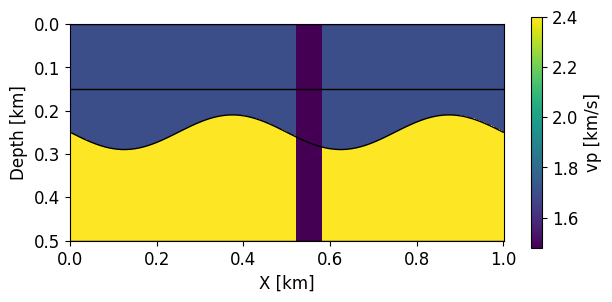

<xarray.Dataset> Size: 367kB
Dimensions:  (x: 151, z: 151)
Coordinates:
  * x        (x) float64 1kB 0.0 0.006667 0.01333 0.02 ... 0.9867 0.9933 1.0
  * z        (z) float64 1kB 0.0 0.003333 0.006667 0.01 ... 0.4933 0.4967 0.5
Data variables:
    rho      (x, z) float64 182kB 1.8 1.8 1.8 1.8 1.8 ... 2.2 2.2 2.2 2.2 2.2
    vp       (x, z) float64 182kB 1.7 1.7 1.7 1.7 1.7 ... 2.4 2.4 2.4 2.4 2.4

In [2]:
x = np.linspace(0.0, 1.0, 101)
interface = xr.DataArray(
    0.25 + 0.04 * np.sin(4.0 * np.pi * x),
    dims=["x"],
    coords={"x": x},
    attrs={"units": "km"},
)
interface.coords["x"].attrs["units"] = "km"

model = fs.LayeredModel(name="model", dimension=2, x_limits=[0.0, 1.0])
model.add_surface(name="top", depth=0.0 * u.km)
model.add_layer(
    name="overburden",
    properties={"Vp": 1.7 * u.km / u.s, "Rho": 1.8 * u.g / u.cm**3},
)
model.add_surface(name="marker", depth=0.15 * u.km)
model.add_surface(name="reservoir_top", depth=interface)
model.add_layer(
    name="reservoir",
    properties={"Vp": 2.4 * u.km / u.s, "Rho": 2.2 * u.g / u.cm**3},
)
model.add_surface(name="bottom", depth=0.5 * u.km)

model.add_borehole(
    name="well_1",
    x=0.55 * u.km,
    top="top",
    bottom="bottom",
    parts=[
        {
            "name": "fluid",
            "mesh_block_id": 20,
            "r": 0.03 * u.km,
            "physics": "acoustic",
            "properties": {"Vp": 1.48 * u.km / u.s, "Rho": 1.0 * u.g / u.cm**3},
        }
    ],
)

uniform = model.sample_uniform([151, 151])
model.plot("vp", figsize=(7, 3), aspect="equal")
uniform


## Inspect The Uniform Model Result

`model.sample_uniform(...)` converts the layered representation into a regular `xarray.Dataset`. This does not replace the layered model used for meshing; it is a QC and export view.

Use the sampled result to answer practical questions before running a solver job: Did the variable interface land at the intended depth? Did the non-interface marker leave material properties unchanged? Are units attached to the sampled coordinates and property arrays? Those checks are much cheaper than discovering a modeling mistake after a remote solve.


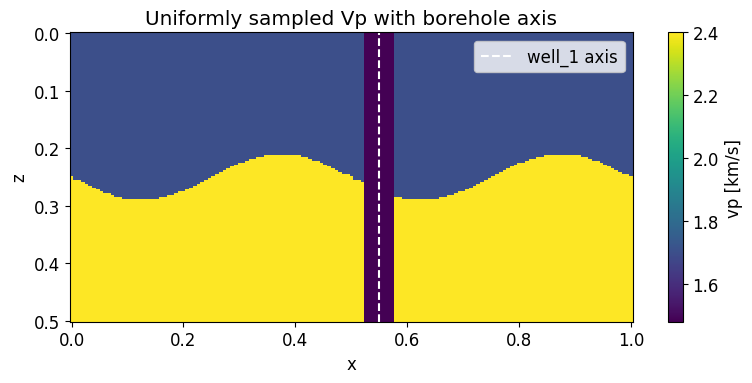

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
uniform["vp"].transpose("z", "x").plot(ax=ax, yincrease=False, cmap="viridis")
ax.axvline(0.55, color="white", linestyle="--", linewidth=1.5, label="well_1 axis")
ax.set_title("Uniformly sampled Vp with borehole axis")
ax.legend()
fig.tight_layout()


## Mesh And Run The Advanced Layered Model

The same model can be attached to a simulation and meshed. `refine_around_borehole(...)` is a geometry-aware mesh-generator control: it keeps the borehole geometry visible to meshing rather than treating it as a generic property blob.


In [ ]:
project = fs.Project(
    name="project",
    pretty_name="advanced_layered_model",
    path="./scratch/tutorials/layered_models",
    log_level="INFO",
    log_to_console=True,
)

sim = project.new_simulation(
    name="advanced_layered_model",
    physics="acoustic",
    dimension=2,
    units={"length": "km", "velocity": "km/s", "density": "g/cm^3"},
)
sim += model

mesh = model.hex_mesh_generator([8, 4])
mesh.refine_around_borehole("well_1", padding=0.04 * u.km, max_size=0.01 * u.km)
sim += mesh
sim.mesh.set_adapt(elems_per_wave=2.0, order=4, f_low=5.0, f_high=30.0)
sim += fs.BoundaryCondition(conditions=["free"], boundaries=["z_min"])
sim += fs.BoundaryCondition(conditions=["pml"], boundaries=["x_min", "x_max", "z_max"], pml_wavelengths=0.75)

acq = fs.Acquisition()
acq.add_sources(kind="scalar", coords=[[0.3, 0.04]])
hydrophone = fs.ReceiverNode(name="hydrophone")
hydrophone.add_component(name="p", field="pressure")
acq.add_receiver_group(name="surface", device=hydrophone, coords=[[x, 0.03] for x in np.linspace(0.1, 0.9, 41)])
sim += acq
sim += fs.Discretization()

site = fs.Site()
job = fs.FrequencyDomainJob(
    name="freq_layered_model",
    simulation=sim,
    f_list=[20.0],
    outputs=[
        fs.VtkOutput.domain(
            name="layered_model",
            fields=["pressure"],
            properties=["vp", "rho", "Subdomain"],
            show_pml=True,
            upscale=1,
            order=2,
        )
    ],
)
result = site.submit(job).wait()


## Render The Layered Mesh/Property Output

The output image is the concrete check that the advanced model exported to the solver and produced a mesh/result file. Open the `.vtu` files in ParaView for more detailed inspection.


In [ ]:
vtu_files = result.output_files(base="layered_model", suffix=".vtu", existing=True)
image_dir = Path("./assets")
image_dir.mkdir(exist_ok=True)
screenshot = image_dir / "layered_model_vp.png"
fs.plot_vtu(
    vtu_files[0],
    field="vp",
    show_edges=True,
    scalar_bar=True,
    show=False,
    screenshot=screenshot,
    window_size=(1100, 500),
)
display(Image(filename=str(screenshot)))


## Before Moving On

Before running a complex layered model, inspect the sampled version and the generated mesh/QC output. The sampled model answers "did I author the geology I intended?" while the mesh and ParaView output answer "did the solver receive geometry and properties that make sense?"

This tutorial should leave users comfortable scaling from simple flat layers to realistic surfaces while preserving a clear audit trail.

## Result Review Checklist

The advanced layered-model run should be reviewed in two passes. First inspect the sampled `xarray.Dataset` because it is cheap and independent of meshing. Then inspect the ParaView screenshot or `.vtu` file because it proves the same geometry survived export, meshing, and solver output.

| Artifact | What to confirm |
| --- | --- |
| Uniform sample | `reservoir_top` changes the material assignment, while `marker` does not introduce a third material interval. |
| Borehole axis overlay | The refinement target is in the intended lateral position and spans the intended top/bottom surfaces. |
| VTU screenshot | Mesh edges refine around the borehole and preserve the layer/interface geometry. |
| Exported project files | Surface names and subdomain names remain readable; they are the names later output requests and mesh controls will reference. |
